# Tiled clustering model
 
This example is similar as the example presented in Figure 1 in Covariate-moderated Empirical Bayes Matrix Factorization  Denault et al 2025  Matrix Factorization
 
**Model description:**


We simulate a matrix $Z=LF^t$  in which $  L $ (but not $  F $) depended on the
2-d locations of the data points. Specifically, we generated a
periodic tiling of $[0,1] \times [0,1]$, randomly labeling each tile
1, 2 or 3. For each data point $i$, we set
$\ell_{ik} = f(x,y)$ if $i$ was in the tile with label $k$, otherwise
$\ell_{ik} = 0$. The $  F $ matrix, by contrast, was simulated from
a simple scale mixture of normals, $f_{jk} \sim \pi_0 \delta_0 +
\sum_{m=1}^M N(0, \sigma_m^2)$. We simulated homoskedastic noise with
$\tau_{ij} = 0.1$.
 

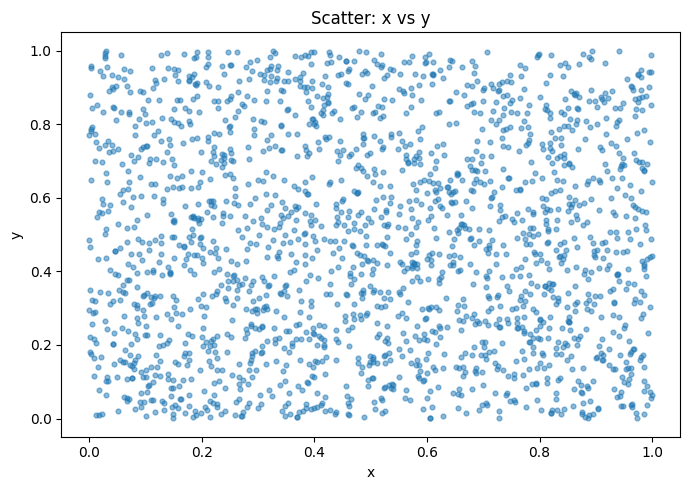

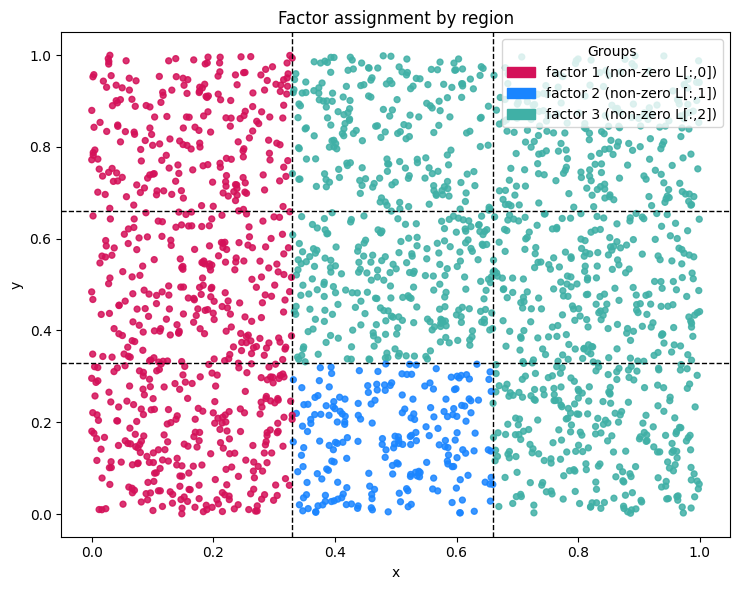

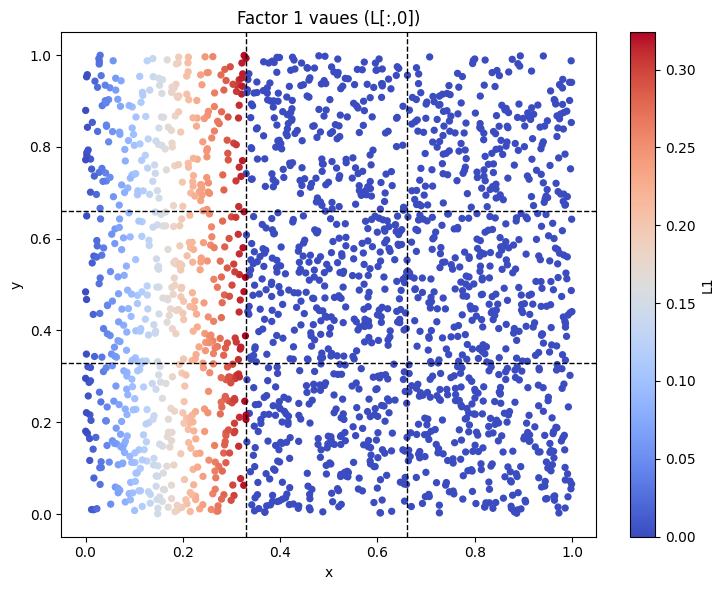

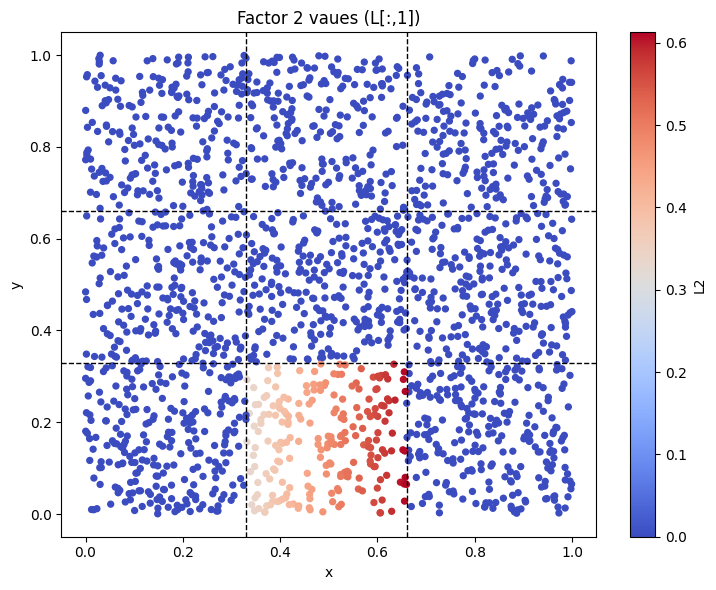

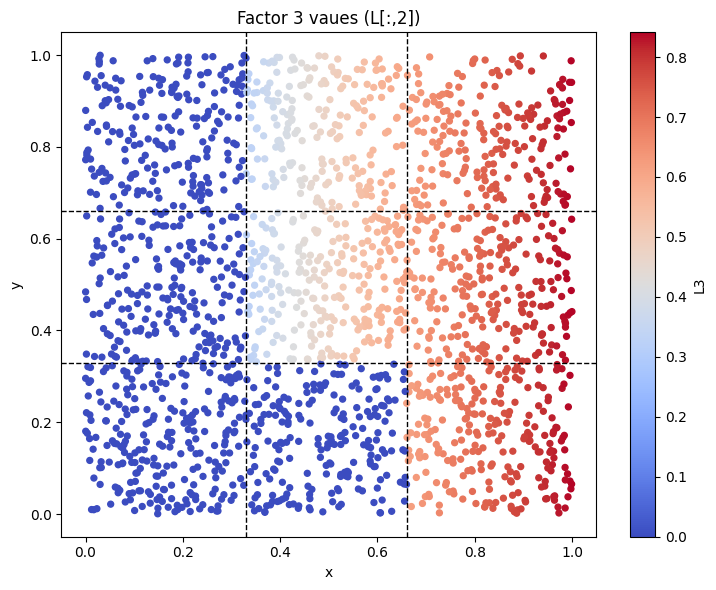

In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =========================
# Config & Reproducibility
# =========================
SEED = 1
N = 2000          # number of (x,y) points
M = 200           # number of features (columns) in f
BOUNDARIES = (0.33, 0.66)  # vertical/horizontal guide lines
NOISE_STD = 1.0   # std-dev for observation noise in Z

torch.manual_seed(SEED)

# =========================
# 1) Random uniform data
# =========================
x = torch.rand(N)
y = torch.rand(N)
X = torch.stack([x, y], dim=1)  # (N, 2) -- kept for clarity/optionally used later

# Quick scatter of x vs y
plt.figure(figsize=(7, 5))
plt.scatter(x.numpy(), y.numpy(), alpha=0.5, s=12)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter: x vs y")
plt.tight_layout()
plt.show()

# =========================
# 2) Generate f (3 x M)
#    f[0,i] ~ t1_i * N(0,1), f[1,i], f[2,i] ~ t2_i * N(0,1)
# =========================
t1 = torch.randint(0, 2, (M,), dtype=torch.float32)  # {0,1}
t2 = torch.randint(0, 2, (M,), dtype=torch.float32)  # {0,1}

f0 = t1 * torch.randn(M)
f1 = t2 * torch.randn(M)
f2 = t2 * torch.randn(M)
f  = torch.stack([f0, f1, f2], dim=0)  # (3, M)

# =========================
# 3) Build L (N x 3) + factor labels
# =========================
L = torch.zeros(N, 3, dtype=torch.float32)

b1, b2 = BOUNDARIES
mask1 = x < b1
mask2 = (~mask1) & (x < b2) & (y < b1)  # second region
mask3 = ~(mask1 | mask2)                # everything else

# Nonzero loadings by region (note: original logic used sin(x) for all three)
L[mask1, 0] = torch.sin(x[mask1])
L[mask2, 1] = torch.sin(x[mask2])
L[mask3, 2] = torch.sin(x[mask3])

# Integer factor labels in {1,2,3}
factor = torch.zeros(N, dtype=torch.long)
factor[mask1] = 1
factor[mask2] = 2
factor[mask3] = 3

# =========================
# 4) Factor visualization
# =========================
colors = ["#D41159", "#1A85FF", "#40B0A6"]  # red, blue, teal
color_map = {1: colors[0], 2: colors[1], 3: colors[2]}
point_colors = [color_map[int(k)] for k in factor.tolist()]

plt.figure(figsize=(7.5, 6))
plt.scatter(x.numpy(), y.numpy(), c=point_colors, s=18, alpha=0.85)
for v in (b1, b2):
    plt.axhline(v, color="black", linestyle="--", linewidth=1)
    plt.axvline(v, color="black", linestyle="--", linewidth=1)
plt.title("Factor assignment by region")
plt.xlabel("x")
plt.ylabel("y")

# Legend (explicit: red = non-zero L[:,0], etc.)
handles = [
    mpatches.Patch(color=colors[0], label="factor 1 (non-zero L[:,0])"),
    mpatches.Patch(color=colors[1], label="factor 2 (non-zero L[:,1])"),
    mpatches.Patch(color=colors[2], label="factor 3 (non-zero L[:,2])"),
]
plt.legend(handles=handles, title="Groups", loc="best", frameon=True)
plt.tight_layout()
plt.show()

# =========================
# 5) Individual factor heatmaps (L1, L2, L3 as color)
# =========================
for i in range(3):
    plt.figure(figsize=(7.5, 6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=L[:, i].numpy(),
        cmap="coolwarm",  # shows magnitude of L[:,i]
        s=18
    )
    for v in (b1, b2):
        plt.axhline(v, color="black", linestyle="--", linewidth=1)
        plt.axvline(v, color="black", linestyle="--", linewidth=1)
    plt.title(f"Factor {i+1} vaues (L[:,{i}])")
    plt.xlabel("x")
    plt.ylabel("y")
    cbar = plt.colorbar()
    cbar.set_label(f"L{i+1}")
    plt.tight_layout()
    plt.show()

# =========================
# 6) Generate observations Z = L @ f + noise
# =========================
noise = NOISE_STD * torch.randn(N, M)
Z = L @ f + noise  # (N, M)

# Optional sanity checks
assert L.shape == (N, 3)
assert f.shape == (3, M)
assert Z.shape == (N, M)


We will factorize the matrix Z using 4 different models.


* EBMF using point mass Laplace without using side information
* cEBMF using a "covariate moderated adaptive shrinkage prior " (cash) $ g(x,y) = \pi_0(x,y) \delta_0 + \sum_{m=1}^M \pi_m (x,y) N(0, \sigma_m^2)  $
* cEBMF using a "covariate moderated generalized binary prior" (cbg) $ g(x,y) = \pi_0(x,y) \delta_0 + (1-\pi_0(x,y))  N(\mu, \sigma_m^2)  $
* cEBMF using a "emprirical mixture of density networks" (emdn) $ g(x,y) = \  \sum_{m=1}^M \pi_m (x,y) N(\mu(x,y), \sigma_m(x,y)^2)  $

Fitting the model without account for the 2d side information

In [2]:
from cebmf_torch import cEBMF
mycebmf=  cEBMF(data=Z ) 
mycebmf.initialise_factors()
mycebmf.fit(10)

CEBMFResult(L=tensor([[-6.7598e+00, -1.4332e-02,  1.8322e+00,  7.3666e-09, -1.6805e-07],
        [-1.2728e-01, -8.6281e-02,  2.0286e+00,  6.0323e-08, -6.9730e-08],
        [-1.6566e+00, -1.5823e-02, -1.1584e-02, -3.5545e-08, -4.5273e-07],
        ...,
        [-6.3495e+00, -9.7502e-01,  1.8474e-02, -1.5771e-08,  5.1932e-07],
        [-1.1016e-01,  6.2751e-02,  2.8442e+00,  7.0515e-08, -1.3537e-08],
        [-9.9256e-02,  1.2566e-01,  1.3082e+00, -2.2852e-08,  6.4646e-08]]), F=tensor([[-1.3574e-01,  1.4970e-01, -8.4925e-02,  1.7955e-20, -9.2379e-20],
        [ 1.6497e-01,  1.4324e-01,  3.9473e-04,  6.2239e-22, -4.8161e-20],
        [-5.1115e-04, -6.7892e-04,  5.7604e-02,  1.2625e-20, -2.6089e-19],
        [-5.5547e-02,  1.2525e-01,  6.6623e-02, -6.9378e-20,  2.1532e-20],
        [ 1.5923e-05, -2.8374e-02,  6.6553e-02, -1.1059e-19, -7.3227e-20],
        [ 1.1018e-03,  1.7563e-03, -4.5966e-04,  6.3003e-21,  1.4014e-20],
        [-1.2125e-05, -9.3930e-03, -5.1896e-04, -1.2304e-19, -1.7528e

[CGB] Epoch 10/10, Loss=8.9769, mu2=-0.155, sigma2=0.924
[CGB] Epoch 10/10, Loss=2.4705, mu2=-0.150, sigma2=0.521
[CGB] Epoch 10/10, Loss=2.2680, mu2=0.058, sigma2=0.271
[CGB] Epoch 10/10, Loss=1.7805, mu2=-0.010, sigma2=0.128
[CGB] Epoch 10/10, Loss=1.7730, mu2=-0.014, sigma2=0.077
[CGB] Epoch 10/10, Loss=7.4982, mu2=-0.314, sigma2=0.449
[CGB] Epoch 10/10, Loss=0.8733, mu2=-0.303, sigma2=0.164
[CGB] Epoch 10/10, Loss=3.1435, mu2=0.037, sigma2=0.000
[CGB] Epoch 10/10, Loss=2.1239, mu2=0.002, sigma2=0.000
[CGB] Epoch 10/10, Loss=1.5204, mu2=0.001, sigma2=0.000
[CGB] Epoch 10/10, Loss=5.3704, mu2=-0.472, sigma2=0.193
[CGB] Epoch 10/10, Loss=-0.4353, mu2=-0.440, sigma2=0.042
[CGB] Epoch 10/10, Loss=-2.2279, mu2=0.018, sigma2=0.000
[CGB] Epoch 10/10, Loss=-4.9985, mu2=-0.000, sigma2=0.000
[CGB] Epoch 10/10, Loss=-6.0323, mu2=0.000, sigma2=0.000
[CGB] Epoch 10/10, Loss=1.7711, mu2=-0.622, sigma2=0.056
[CGB] Epoch 10/10, Loss=-0.7752, mu2=-0.467, sigma2=0.000
[CGB] Epoch 10/10, Loss=-5.8769,

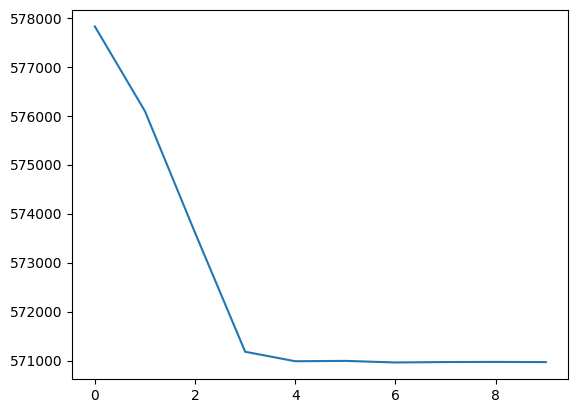

In [3]:
mycebmf31=  cEBMF(data=Z, X_l=X,
                 prior_L="cgb_sharp" , allow_backfitting=False) 
mycebmf31.initialise_factors()
mycebmf31.fit(10)

plt.plot(mycebmf31.obj)

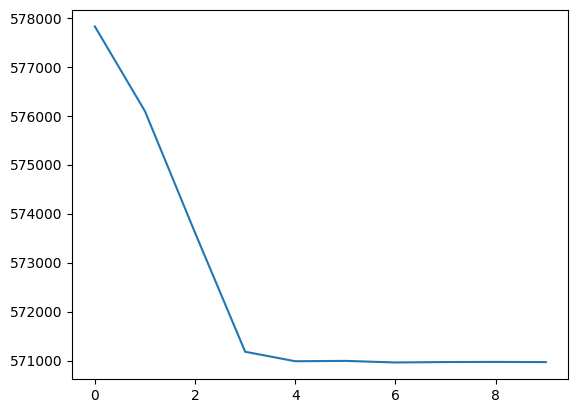

In [4]:
plt.plot(mycebmf31.obj)

Fitting the cEBMF model


Here we store the side information for the rows $L$ in the matrix $X$ that we pass in argument X_l (covariate for L)
Using prior   a "covariate moderated adaptive shrinkage prior " (cash) $ g(x,y) = \pi_0(x,y) \delta_0 + \sum_{m=1}^M \pi_m (x,y) N(0, \sigma_m^2)  $


In [5]:
mycebmf11=  cEBMF(data=Z, X_l=X,
                 prior_L="cash" , allow_backfitting=False) 
mycebmf11.initialise_factors()
mycebmf11.fit(10)


[CASH] Epoch 10/10 | Loss: 396.2574
[CASH] Epoch 10/10 | Loss: 220.5953
[CASH] Epoch 10/10 | Loss: 242.4368
[CASH] Epoch 10/10 | Loss: 222.3919
[CASH] Epoch 10/10 | Loss: 222.1686
[CASH] Epoch 10/10 | Loss: 385.4779
[CASH] Epoch 10/10 | Loss: 210.8279
[CASH] Epoch 10/10 | Loss: 227.2709
[CASH] Epoch 10/10 | Loss: 195.3879
[CASH] Epoch 10/10 | Loss: 209.5817
[CASH] Epoch 10/10 | Loss: 381.1527
[CASH] Epoch 10/10 | Loss: 209.8208
[CASH] Epoch 10/10 | Loss: 226.0009
[CASH] Epoch 10/10 | Loss: -1069.7703
[CASH] Epoch 10/10 | Loss: -1001.6793
[CASH] Epoch 10/10 | Loss: 378.8881
[CASH] Epoch 10/10 | Loss: 209.3441
[CASH] Epoch 10/10 | Loss: 225.8264
[CASH] Epoch 10/10 | Loss: -1289.3816
[CASH] Epoch 10/10 | Loss: -1289.3816
[CASH] Epoch 10/10 | Loss: 378.1289
[CASH] Epoch 10/10 | Loss: 208.9420
[CASH] Epoch 10/10 | Loss: 225.9876
[CASH] Epoch 10/10 | Loss: -1289.3869
[CASH] Epoch 10/10 | Loss: -1289.3869
[CASH] Epoch 10/10 | Loss: 377.6941
[CASH] Epoch 10/10 | Loss: 209.3585
[CASH] Epoch 10/

CEBMFResult(L=tensor([[-6.9195e+00, -4.3440e-44,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [-1.1800e-17,  0.0000e+00,  2.2086e+00,  0.0000e+00,  0.0000e+00],
        [-1.4776e+00,  0.0000e+00, -2.2088e-20,  0.0000e+00,  0.0000e+00],
        ...,
        [-6.5166e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [-2.8006e-23,  3.7475e-26,  2.8653e+00,  0.0000e+00,  0.0000e+00],
        [-3.4075e-35,  1.2193e-23,  1.1936e+00,  0.0000e+00,  0.0000e+00]]), F=tensor([[-1.3431e-01,  1.5435e-01, -1.0045e-01,  0.0000e+00,  0.0000e+00],
        [ 1.6454e-01,  1.5392e-01,  1.6015e-03,  0.0000e+00,  0.0000e+00],
        [-4.5735e-04, -1.0002e-03,  3.4300e-02,  0.0000e+00,  0.0000e+00],
        [-5.5158e-02,  1.2735e-01,  7.4733e-02,  0.0000e+00,  0.0000e+00],
        [ 9.3935e-06, -3.7617e-02,  7.7673e-02,  0.0000e+00,  0.0000e+00],
        [ 9.8409e-04,  2.7716e-03, -6.6824e-04,  0.0000e+00,  0.0000e+00],
        [-2.4133e-05, -1.2066e-02, -1.0345e-03,  0.0000e+00,  0.0000e

The ELBO is not purely monotonic for cEBMF using because the prior learning uses SGD

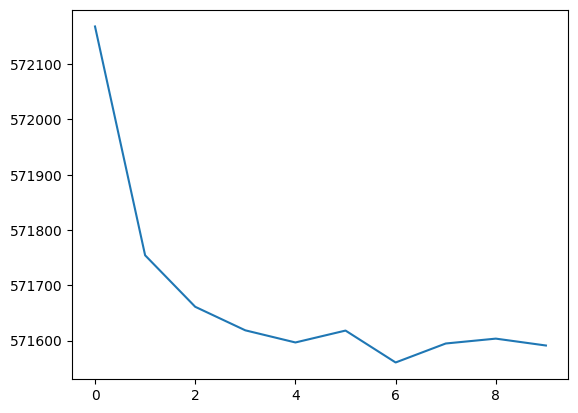

In [6]:

plt.plot(mycebmf11.obj)

Fitting the cEBMF model using a "covariate moderated generalized binary prior" (cbg) $ g(x,y) = \pi_0(x,y) \delta_0 + (1-\pi_0) (x,y) N(\mu, \sigma_m^2)  $
 

[CGB] Epoch 10/10, Loss=3.1049, mu2=-0.149, sigma2=6.595
[CGB] Epoch 10/10, Loss=1.7622, mu2=-0.104, sigma2=4.369
[CGB] Epoch 10/10, Loss=1.9286, mu2=0.117, sigma2=2.654
[CGB] Epoch 10/10, Loss=1.7664, mu2=-0.014, sigma2=2.215
[CGB] Epoch 10/10, Loss=1.7649, mu2=-0.015, sigma2=2.211
[CGB] Epoch 10/10, Loss=3.0450, mu2=-0.308, sigma2=6.462
[CGB] Epoch 10/10, Loss=1.6878, mu2=-0.256, sigma2=4.421
[CGB] Epoch 10/10, Loss=1.8216, mu2=0.268, sigma2=2.669
[CGB] Epoch 10/10, Loss=1.6304, mu2=-0.034, sigma2=3.398
[CGB] Epoch 10/10, Loss=1.6532, mu2=-0.030, sigma2=2.837
[CGB] Epoch 10/10, Loss=3.0220, mu2=-0.468, sigma2=6.311
[CGB] Epoch 10/10, Loss=1.6769, mu2=-0.410, sigma2=4.296
[CGB] Epoch 10/10, Loss=1.7855, mu2=0.422, sigma2=2.535
[CGB] Epoch 10/10, Loss=4.8032, mu2=-0.030, sigma2=0.001
[CGB] Epoch 10/10, Loss=4.2400, mu2=-0.024, sigma2=0.001
[CGB] Epoch 10/10, Loss=2.9976, mu2=-0.628, sigma2=6.152
[CGB] Epoch 10/10, Loss=1.6630, mu2=-0.563, sigma2=4.142
[CGB] Epoch 10/10, Loss=1.7493, mu

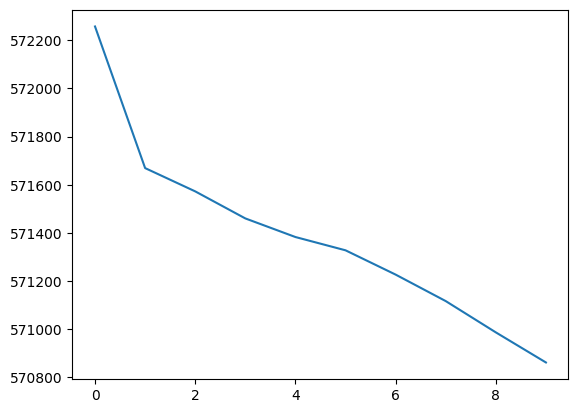

In [7]:
mycebmf12=  cEBMF(data=Z, X_l=X,
                 prior_L="cgb" , allow_backfitting=False) 
mycebmf12.initialise_factors()
mycebmf12.fit(10)

plt.plot(mycebmf12.obj)

Fitting the cEBMF model using a "emprirical mixture of density networks" (emdn) $ g(x,y) = \  \sum_{m=1}^M \pi_m (x,y) N(\mu(x,y), \sigma_m(x,y)^2)  $

In [8]:
mycebmf13=  cEBMF(data=Z, X_l=X,
                 prior_L="emdn", allow_backfitting=False) 
mycebmf13.initialise_factors()
mycebmf13.fit(10)



[EMDN] Epoch 10/10, Loss: 2.9445
[EMDN] Epoch 10/10, Loss: 1.6594
[EMDN] Epoch 10/10, Loss: 1.6997
[EMDN] Epoch 10/10, Loss: 1.6817
[EMDN] Epoch 10/10, Loss: 1.6792
[EMDN] Epoch 10/10, Loss: 1.7800
[EMDN] Epoch 10/10, Loss: 1.4969
[EMDN] Epoch 10/10, Loss: 1.6228
[EMDN] Epoch 10/10, Loss: 1.6803
[EMDN] Epoch 10/10, Loss: 1.6826
[EMDN] Epoch 10/10, Loss: 1.5877
[EMDN] Epoch 10/10, Loss: 1.4511
[EMDN] Epoch 10/10, Loss: 1.4783
[EMDN] Epoch 10/10, Loss: 1.6744
[EMDN] Epoch 10/10, Loss: 1.6781
[EMDN] Epoch 10/10, Loss: 1.5409
[EMDN] Epoch 10/10, Loss: 1.4348
[EMDN] Epoch 10/10, Loss: 1.4762
[EMDN] Epoch 10/10, Loss: 1.6706
[EMDN] Epoch 10/10, Loss: 1.6725
[EMDN] Epoch 10/10, Loss: 1.5174
[EMDN] Epoch 10/10, Loss: 1.4337
[EMDN] Epoch 10/10, Loss: 1.4654
[EMDN] Epoch 10/10, Loss: 1.6678
[EMDN] Epoch 10/10, Loss: 1.6618
[EMDN] Epoch 10/10, Loss: 1.5234
[EMDN] Epoch 10/10, Loss: 1.3818
[EMDN] Epoch 10/10, Loss: 1.4356
[EMDN] Epoch 10/10, Loss: 1.6582
[EMDN] Epoch 10/10, Loss: 1.6595
[EMDN] Epo

CEBMFResult(L=tensor([[-7.1540e+00,  2.0026e-02,  4.4308e-03, -1.4676e-01, -1.4684e-01],
        [-3.1333e-01, -3.4315e-02,  3.0222e+00,  4.5693e-01, -3.4036e-01],
        [-3.8369e+00, -7.3861e-03, -5.4746e-04, -3.7831e-01, -2.4462e-01],
        ...,
        [-6.6036e+00,  5.8326e-02,  1.1493e-02, -2.1720e-01,  6.6119e-01],
        [-3.3962e-01,  1.3129e-03,  2.9671e+00,  3.0521e-01,  9.4727e-01],
        [-3.2028e-01,  5.0144e-03,  2.6473e+00, -7.6642e-02,  4.7787e-01]]), F=tensor([[-1.2974e-01,  1.7517e-01, -1.1964e-01,  6.6179e-04, -2.3729e-03],
        [ 1.6171e-01,  1.2377e-01,  3.4832e-02, -1.9066e-04, -3.0111e-03],
        [-1.2345e-03, -1.8748e-03,  6.4318e-02,  3.3255e-04, -2.5779e-01],
        [-5.3070e-02,  1.4194e-01,  8.8267e-02, -1.3392e-03, -1.5364e-03],
        [ 1.5940e-05, -4.0504e-02,  8.2371e-02, -8.5185e-04, -1.7360e-03],
        [ 1.3020e-03,  2.9831e-03,  1.1111e-03,  1.0610e-03, -8.9866e-05],
        [ 4.8563e-05, -1.1226e-02, -2.7352e-03, -1.6312e-01,  4.3065e

we can visualized the corresponding values to the negative ELBO (lower the better)

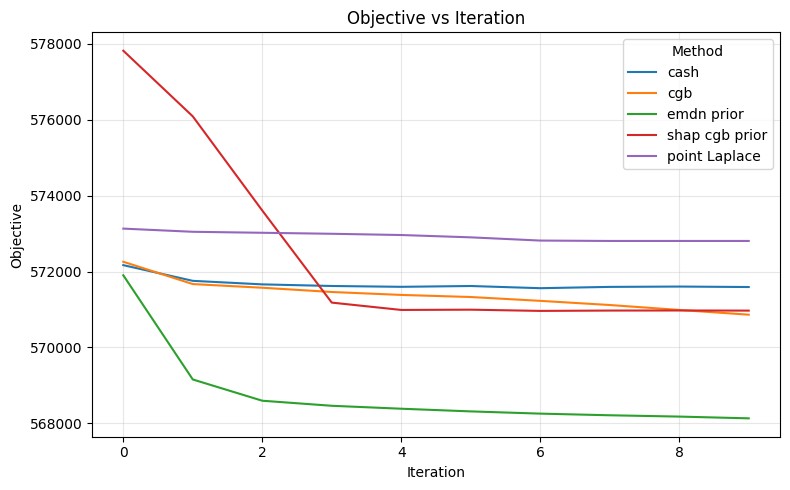

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def to1d(a):
    if isinstance(a, torch.Tensor):
        return a.detach().cpu().flatten().numpy()
    return np.asarray(a).ravel()

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(to1d(mycebmf11.obj), label="cash")
ax.plot(to1d(mycebmf12.obj), label="cgb")
ax.plot(to1d(mycebmf13.obj), label="emdn prior")
ax.plot(to1d(mycebmf31.obj), label="shap cgb prior")
ax.plot(to1d(mycebmf.obj),  label="point Laplace")

ax.set_title("Objective vs Iteration")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective")
ax.legend(title="Method", loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The results is not surprising as in this case only the emdn prior can recover the data generating process thus leading to a better fit.


The worst is acheived by the EBMF model with point Laplace which is the least flexible model


Noe 

RMSE Point Laplace tensor(0.0087)
RMSE cash tensor(0.0066)
RMSE cgb tensor(0.0053)
RMSE emdn tensor(0.0026)
RMSE emdn tensor(0.0145)


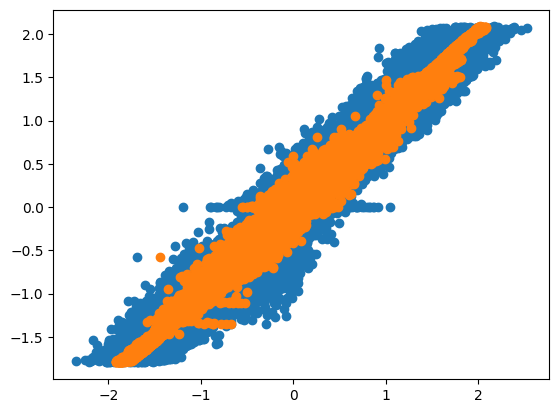

In [10]:
mycebmf._update_fitted_value()
mycebmf11._update_fitted_value()
mycebmf12._update_fitted_value()
mycebmf13._update_fitted_value()
mycebmf31._update_fitted_value()

plt.scatter(mycebmf.Y_fit,L@f)
plt.scatter(mycebmf13.Y_fit,L@f)
print("RMSE Point Laplace",torch.mean((mycebmf.Y_fit-L@f).pow(2)))

print("RMSE cash",torch.mean((mycebmf11.Y_fit-L@f).pow(2)))
print("RMSE cgb",torch.mean((mycebmf12.Y_fit-L@f).pow(2)))
print("RMSE emdn",torch.mean((mycebmf13.Y_fit-L@f).pow(2)))
print("RMSE emdn",torch.mean((mycebmf31.Y_fit-L@f).pow(2)))

Fitted factors (emdn prior)

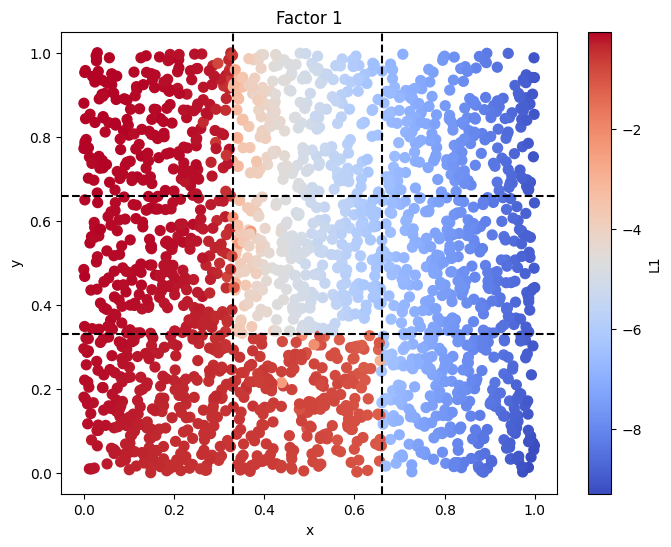

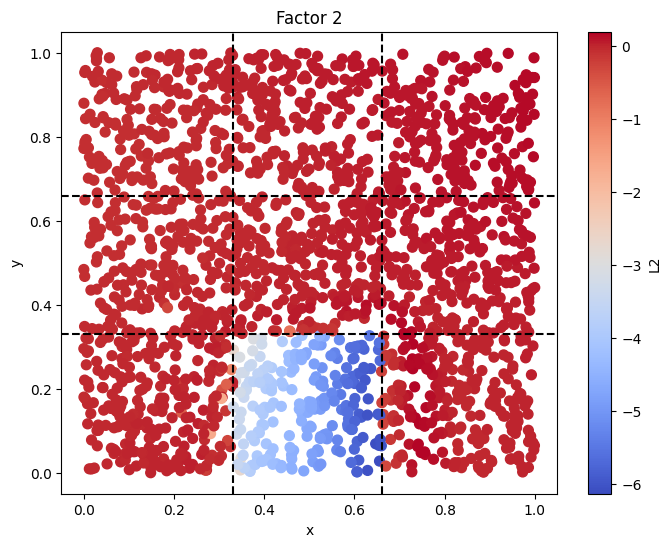

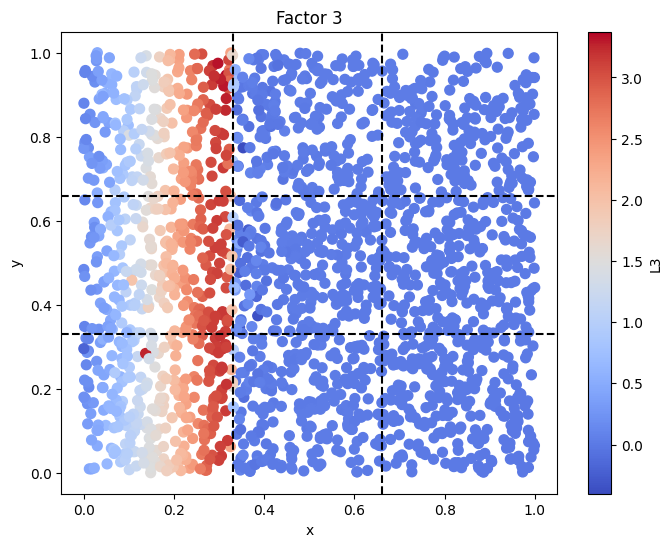

In [11]:
for i in range(3):
    plt.figure(figsize=(8,6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=mycebmf13.L[:, i].numpy(),
        cmap="coolwarm",
        s=50
    )
    for v in [0.33, 0.66]:
        plt.axhline(v, color="black", linestyle="--")
        plt.axvline(v, color="black", linestyle="--")
    plt.title(f"Factor {i+1}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar(label=f"L{i+1}")
    plt.show()


Fitted factors (point Laplace)

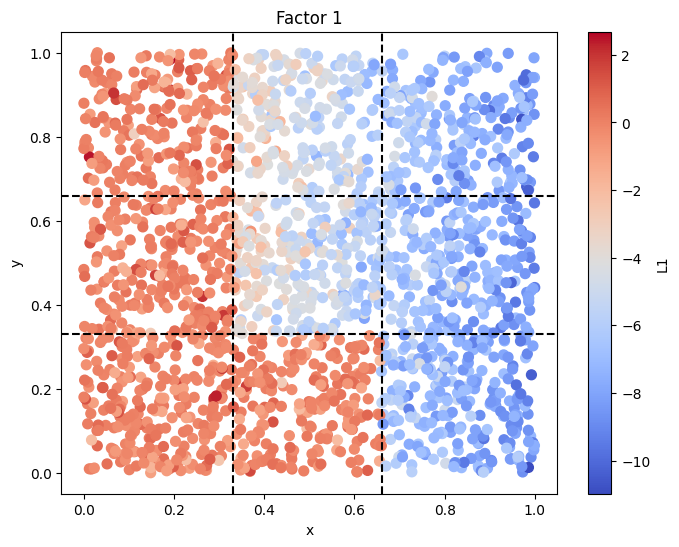

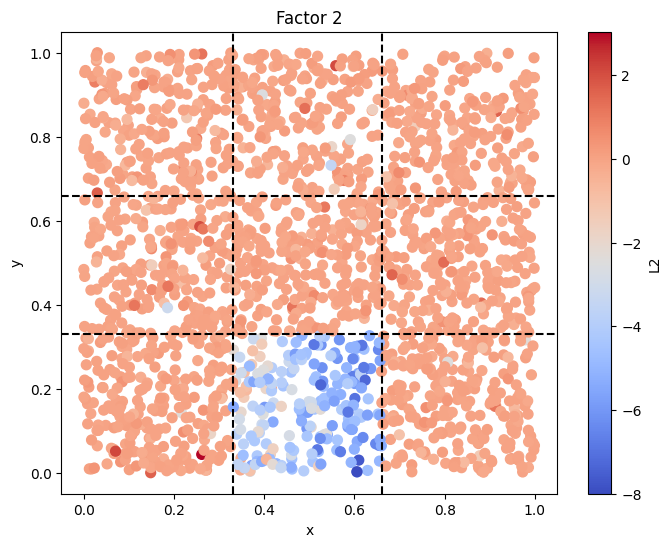

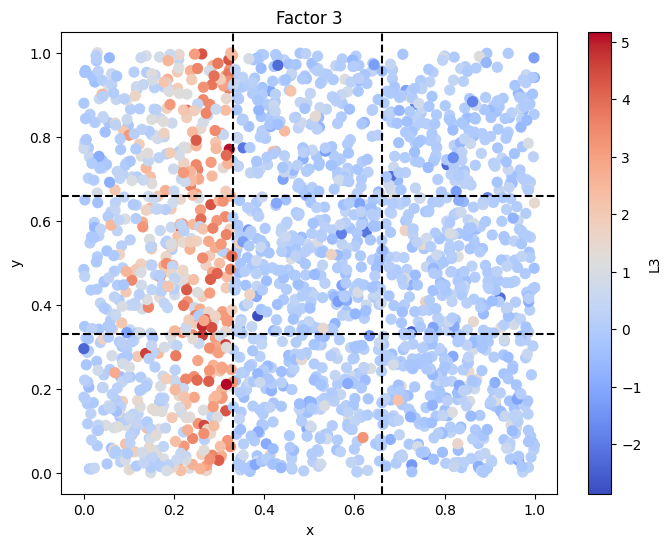

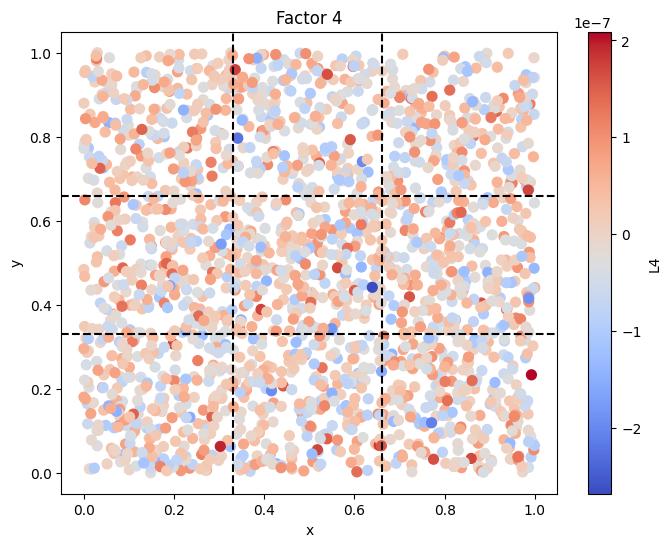

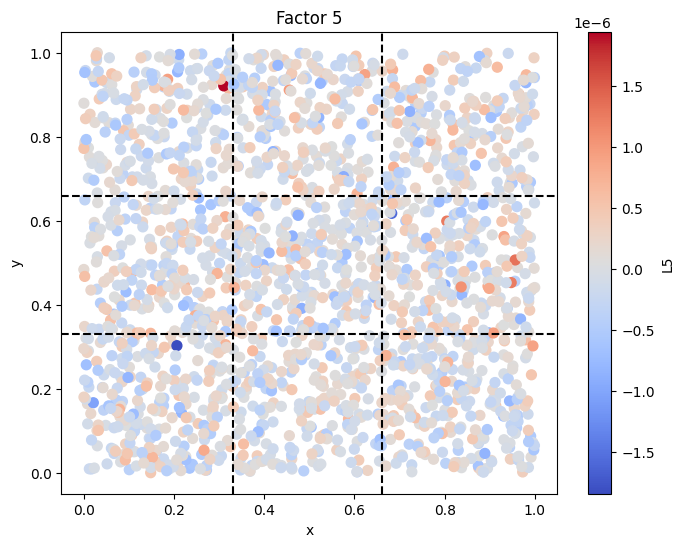

In [12]:
for i in range(5):
    plt.figure(figsize=(8,6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=mycebmf.L[:, i].numpy(),
        cmap="coolwarm",
        s=50
    )
    for v in [0.33, 0.66]:
        plt.axhline(v, color="black", linestyle="--")
        plt.axvline(v, color="black", linestyle="--")
    plt.title(f"Factor {i+1}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar(label=f"L{i+1}")
    plt.show()


We can visulaized the fitted factor for the different prior 

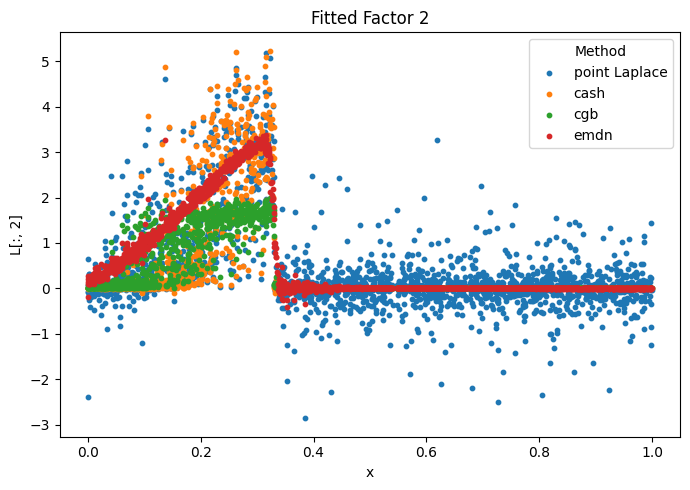

In [13]:
k = 2

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(x.detach().cpu().numpy(), mycebmf.L[:,k].detach().cpu().numpy(), s=10, label="point Laplace")
ax.scatter(x.detach().cpu().numpy(), mycebmf11.L[:,k].detach().cpu().numpy(), s=10, label="cash")
ax.scatter(x.detach().cpu().numpy(), mycebmf12.L[:,k].detach().cpu().numpy(), s=10, label="cgb")
ax.scatter(x.detach().cpu().numpy(), mycebmf13.L[:,k].detach().cpu().numpy(), s=10, label="emdn")

ax.set_title(f"Fitted Factor {k}")
ax.set_xlabel("x"); ax.set_ylabel(f"L[:, {k}]")
ax.legend(title="Method", loc="best")
plt.tight_layout()
plt.show()
